In [2]:
!pip install torchxrayvision -q

import torchxrayvision as xrv
import torch

# Load pretrained CXR8 model
model = xrv.models.DenseNet(weights="densenet121-res224-nih")
model.eval()

print("Model loaded")
print(f"Pathologies ({len(model.pathologies)}):")
for i, p in enumerate(model.pathologies):
    print(f"   {i+1:>2}. {p}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 57.4 MB/s eta 0:00:00:00:0100:01
If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/nih-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt -O /root/.torchxrayvision/models_data/nih-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt`
[██████████████████████████████████████████████████]
Model loaded
Pathologies (18):
    1. Atelectasis
    2. Consolidation
    3. Infiltration
    4. Pneumothorax
    5. Edema
    6. Emphysema
    7. Fibrosis
    8. Effusion
    9. Pneumonia
   10. Pleural_Thickening
   11. Cardiomegaly
   12. Nodule
   13. Mass
   14. Hernia
   15. 
   16. 
   17. 
   18. 


In [3]:
import torchxrayvision as xrv
import torchvision.transforms as transforms
import torch
import numpy as np
import skimage.io

# test image from CXR8
import glob
DATA_DIR = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
sample_img_path = glob.glob(f"{DATA_DIR}/images_001/images/*.png")[0]
print(f"Testing on: {sample_img_path}")

# Load & preprocess 
img = skimage.io.imread(sample_img_path)
img = xrv.datasets.normalize(img, 255)

# Handle grayscale vs RGB
if len(img.shape) == 3:
    img = img.mean(axis=2)  # convert to grayscale

img = img[None, ...]  # add channel dim → (1, H, W)

transform = transforms.Compose([
    xrv.datasets.XRayCenterCrop(),
    xrv.datasets.XRayResizer(224)
])
img = transform(img)
img_tensor = torch.from_numpy(img).unsqueeze(0)  # (1, 1, 224, 224)

print(f"Image shape : {img_tensor.shape}")

# Inference 
with torch.no_grad():
    preds = model(img_tensor).squeeze()

Testing on: /kaggle/input/datasets/organizations/nih-chest-xrays/data/images_001/images/00000502_003.png
Image shape : torch.Size([1, 1, 224, 224])


In [4]:
import pandas as pd

# Check what the actual label is for this image
DATA_DIR = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
df = pd.read_csv(f"{DATA_DIR}/Data_Entry_2017.csv")

img_name = "00000502_003.png"
row = df[df["Image Index"] == img_name]
print(f"Image : {img_name}")
print(f"True label : {row['Finding Labels'].values[0]}")

Image : 00000502_003.png
True label : Infiltration


In [5]:
import pandas as pd

# Display predictions for all pathologies
print(f"{'Pathology':<25} {'Score':>8}  {'Bar'}")
print("─" * 55)

for i, (path, score) in enumerate(zip(model.pathologies, preds)):
    if path.strip() == "":
        continue  # skip empty slots
    bar = "█" * int(score.item() * 30)
    marker = " ← TRUE LABEL" if path == "Infiltration" else ""
    print(f"{path:<25} {score.item():>8.4f}  {bar}{marker}")

Pathology                    Score  Bar
───────────────────────────────────────────────────────
Atelectasis                 0.5764  █████████████████
Consolidation               0.5196  ███████████████
Infiltration                0.5058  ███████████████ ← TRUE LABEL
Pneumothorax                0.5204  ███████████████
Edema                       0.5434  ████████████████
Emphysema                   0.5234  ███████████████
Fibrosis                    0.1194  ███
Effusion                    0.5002  ███████████████
Pneumonia                   0.5018  ███████████████
Pleural_Thickening          0.1396  ████
Cardiomegaly                0.4753  ██████████████
Nodule                      0.3979  ███████████
Mass                        0.4685  ██████████████
Hernia                      0.1677  █████


In [7]:
import torch
import torch.nn.functional as F
import numpy as np

class GradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        target_layer = self.model.features.denseblock4

        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        target_layer.register_forward_hook(forward_hook)
        target_layer.register_full_backward_hook(backward_hook)

    def generate(self, img_tensor, pathology_idx):
        self.model.zero_grad()
        img_tensor = img_tensor.requires_grad_(True)

        output = self.model(img_tensor)
        score = output[0, pathology_idx]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = cam.squeeze().cpu().numpy()
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()

        cam = torch.tensor(cam).unsqueeze(0).unsqueeze(0)
        cam = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
        return cam.squeeze().numpy()

# Init
gradcam = GradCAM(model)
print("✅ GradCAM ready")

✅ GradCAM ready


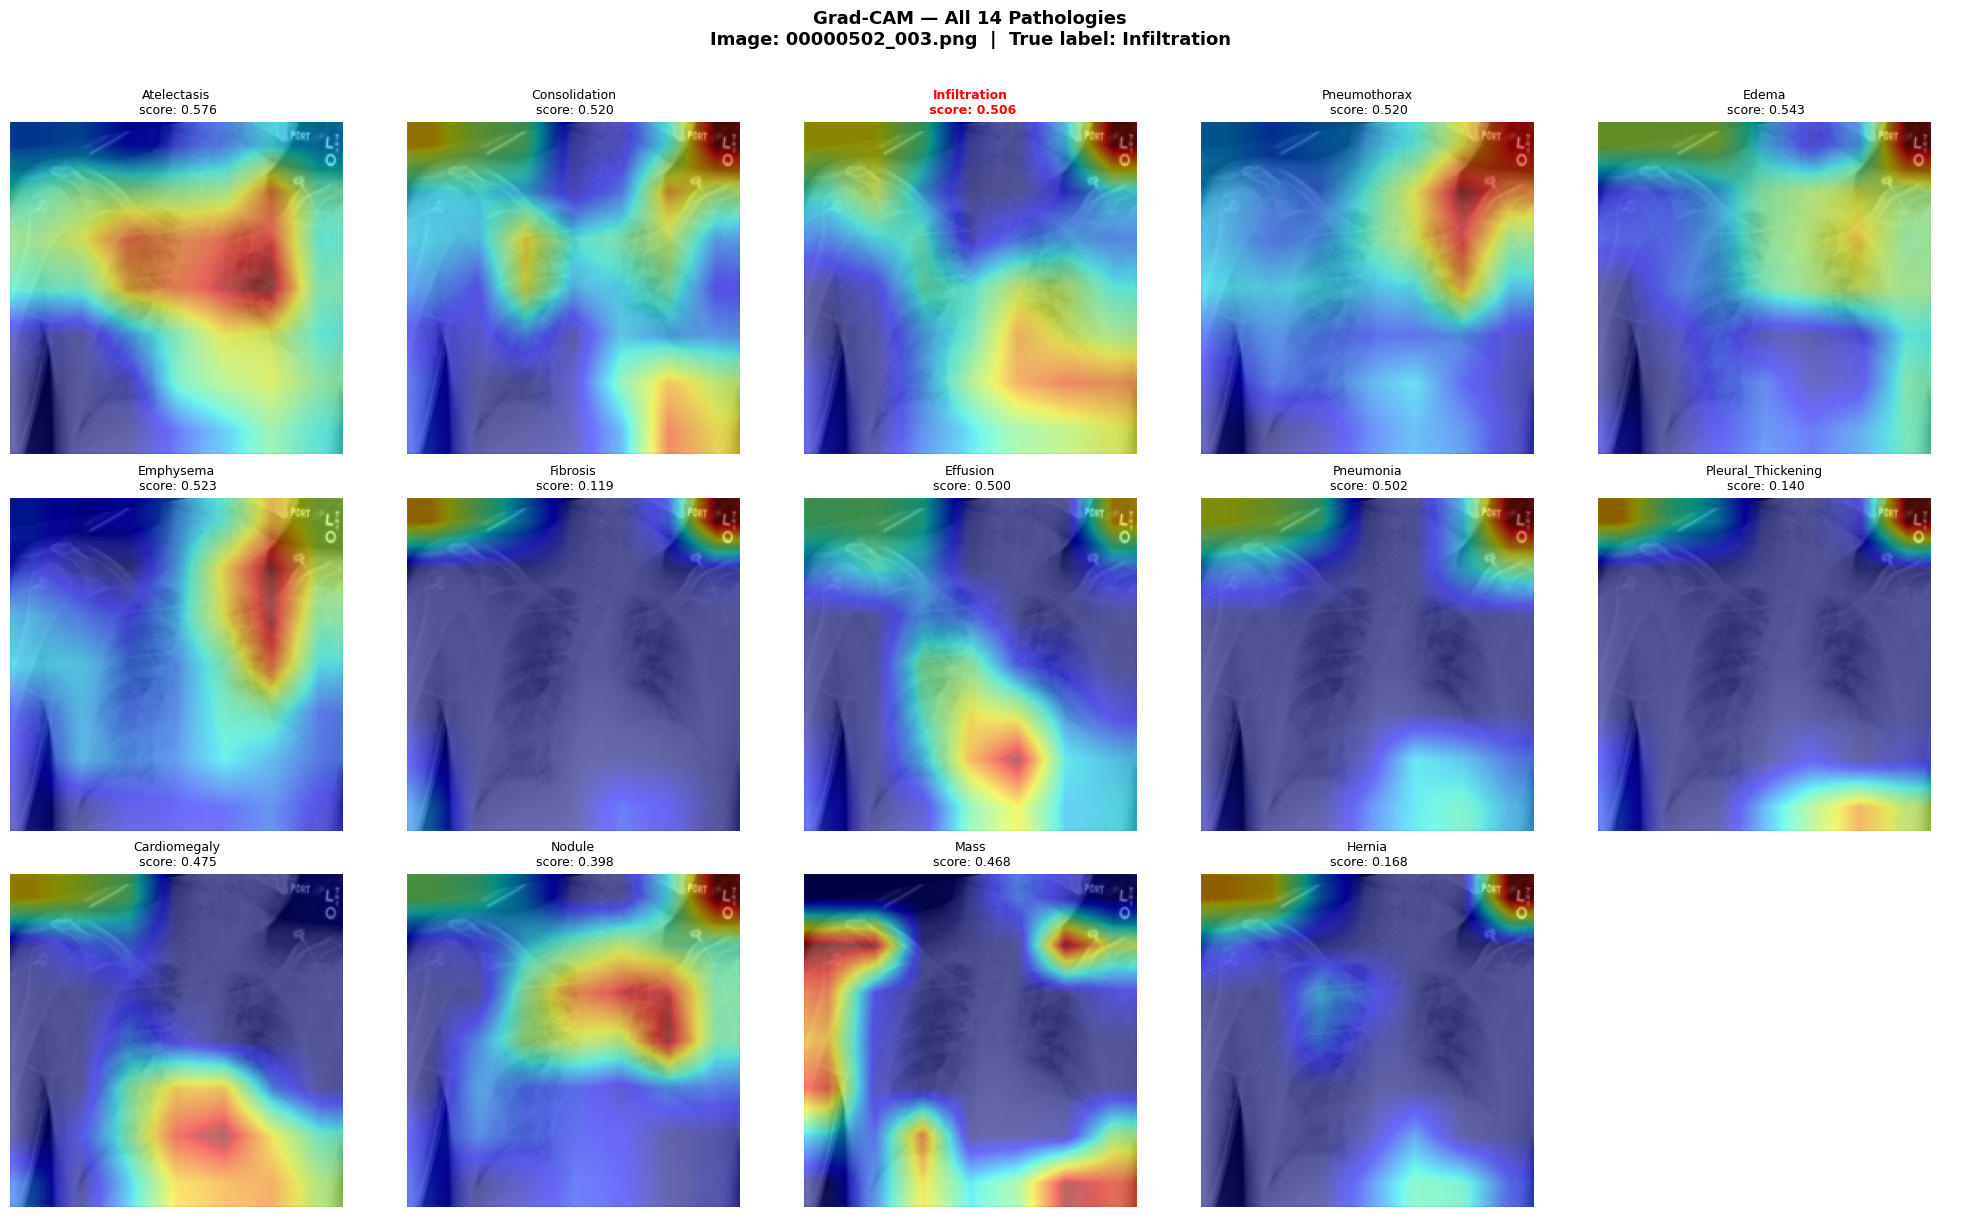

✅ Saved → gradcam_all14.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
import numpy as np

# Original image for overlay (224x224, normalized back to [0,1])
orig_img = img_tensor.squeeze().cpu().numpy()
orig_img = (orig_img - orig_img.min()) / (orig_img.max() - orig_img.min())

# Only named pathologies
named = [(i, p) for i, p in enumerate(model.pathologies) if p.strip() != ""]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for ax_idx, (path_idx, path_name) in enumerate(named):
    cam = gradcam.generate(img_tensor, path_idx)

    # Overlay: colormap on CAM, blended with original
    heatmap = cm.jet(cam)[:, :, :3]
    orig_rgb = np.stack([orig_img] * 3, axis=-1)
    overlay = 0.45 * orig_rgb + 0.55 * heatmap

    score = preds[path_idx].item()

    ax = axes[ax_idx]
    ax.imshow(overlay)
    ax.set_title(f"{path_name}\n score: {score:.3f}", fontsize=9,
                 color="red" if path_name == "Infiltration" else "black",
                 fontweight="bold" if path_name == "Infiltration" else "normal")
    ax.axis("off")

# Hide unused subplot
axes[-1].axis("off")

plt.suptitle("Grad-CAM — All 14 Pathologies\nImage: 00000502_003.png  |  True label: Infiltration",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("gradcam_all14.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → gradcam_all14.png")